# Project - 3 : Car Price Prediction with Machine Learning

## Objective
Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.
## Tech Stack
Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook


### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [2]:
df = pd.read_csv("cardekho.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


### Basic Information about Data

In [4]:
df.shape

(8128, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [6]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


### Missing Values

In [7]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

### Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [10]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

### Clean Categorical Values

In [11]:
cat_cols=['fuel','seller_type','transmission','owner']

for col in cat_cols:
    df[col]=df[col].str.lower().str.strip()

### Clean max_power

In [12]:
df["max_power"]=df["max_power"].astype(str)

df["max_power"]=df["max_power"].str.replace(" bhp","")

df["max_power"]=pd.to_numeric(df["max_power"],errors="coerce")

### Handle Missing Values

In [13]:
num_cols=[
'engine',
'mileage(km/ltr/kg)',
'max_power',
'seats'
]

for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

In [14]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

## Feature Engineering

### Car Age

In [15]:
current_year=2025

df["car_age"]=current_year-df["year"]

### Extract Brand

In [16]:
df["brand"]=df["name"].str.split().str[0]

In [17]:
df[["name","brand"]].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


## Exploratory Data Analysis

### Price Distribution

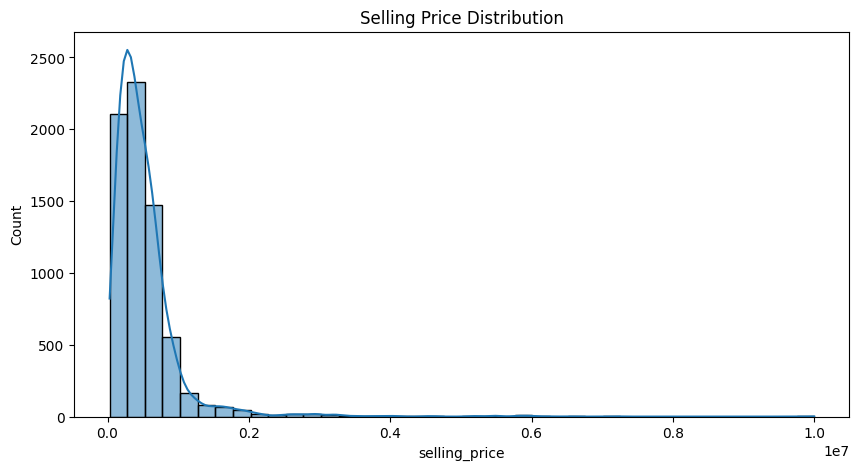

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df["selling_price"],bins=40,kde=True)
plt.title("Selling Price Distribution")
plt.show()

### Price vs Fuel Type

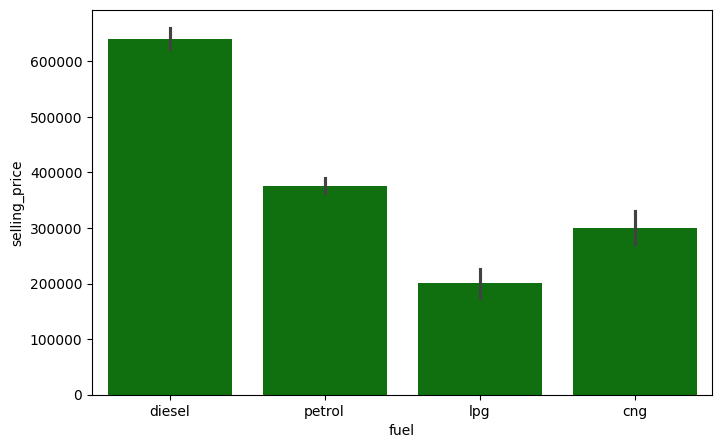

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x="fuel",y="selling_price",data=df,color="green")
plt.show()

### Price vs Car Age

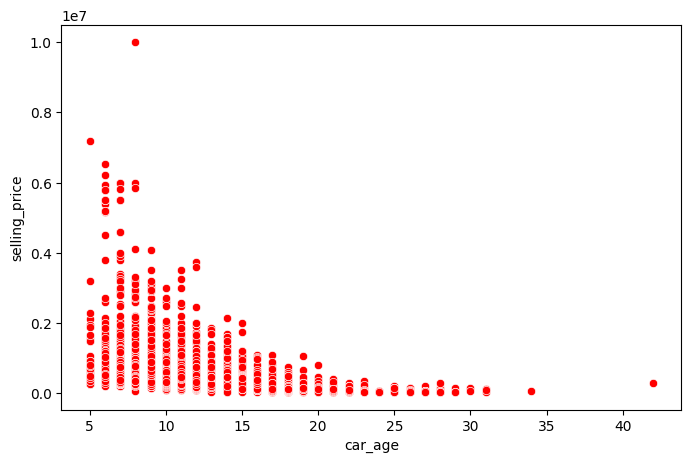

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="car_age",y="selling_price",data=df,color="red")
plt.show()

##### Observation 
Older cars should clearly show lower prices.

### Correlation Heatmap

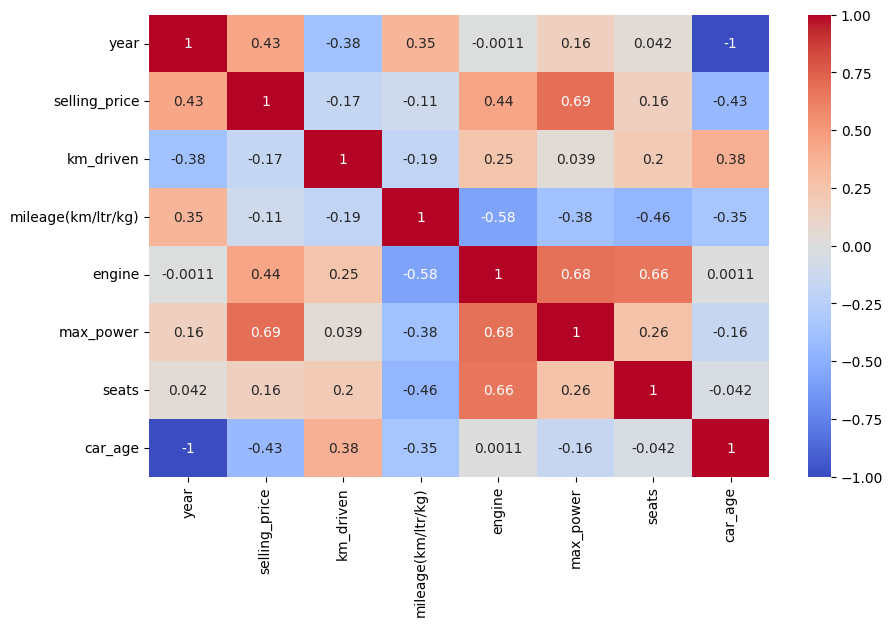

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Feature Selection

In [26]:
X=df.drop(columns=[
    "selling_price",
    "year",
    "name"
])

y=df["selling_price"]

### Identify Columns

In [27]:
categorical_features=[
'fuel',
'seller_type',
'transmission',
'owner',
'brand'
]

numeric_features=[
'km_driven',
'mileage(km/ltr/kg)',
'engine',
'max_power',
'seats',
'car_age'
]

### Preprocessing

In [28]:
preprocessor=ColumnTransformer(
[
(
'cat',
OneHotEncoder(handle_unknown='ignore'),
categorical_features
),
(
'num',
'passthrough',
numeric_features
)
]
)

### Train-Test Split

In [29]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

### Model 1 : Linear Regression

In [30]:
lr_pipeline=Pipeline(
[
('preprocessor',preprocessor),
('model',LinearRegression())
]
)

lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Prediction

In [31]:
lr_pred=lr_pipeline.predict(X_test)

#### Evaluation

In [32]:
print("Linear Regression")

print("MAE:",mean_absolute_error(y_test,lr_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,lr_pred)))

print("R2:",r2_score(y_test,lr_pred))

Linear Regression
MAE: 167801.86932974428
RMSE: 298169.0907643701
R2: 0.5946373027527141


### Model 2 : Random Forest

In [34]:
rf_pipeline=Pipeline(
[
('preprocessor',preprocessor),
('model',RandomForestRegressor(
n_estimators=300,
random_state=42
))
]
)

rf_pipeline.fit(X_train,y_train)

rf_pred=rf_pipeline.predict(X_test)

#### Evaluation

In [35]:
print("Random Forest")

print("MAE:",mean_absolute_error(y_test,rf_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))

print("R2:",r2_score(y_test,rf_pred))

Random Forest
MAE: 72801.18953665602
RMSE: 126965.93536179281
R2: 0.9264990466743726


### Model 3 : Gradient Boosting

In [36]:
gb_pipeline=Pipeline(
[
('preprocessor',preprocessor),
('model',GradientBoostingRegressor(
random_state=42
))
]
)

gb_pipeline.fit(X_train,y_train)

gb_pred=gb_pipeline.predict(X_test)

#### Evaluation

In [37]:
print("Gradient Boosting")

print("MAE:",mean_absolute_error(y_test,gb_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,gb_pred)))

print("R2:",r2_score(y_test,gb_pred))

Gradient Boosting
MAE: 82869.07463785281
RMSE: 131391.51807946415
R2: 0.9212857793308703


### Compare Models

In [38]:
results=pd.DataFrame({

'Model':[
'Linear Regression',
'Random Forest',
'Gradient Boosting'
],

'MAE':[

mean_absolute_error(y_test,lr_pred),

mean_absolute_error(y_test,rf_pred),

mean_absolute_error(y_test,gb_pred)

],

'RMSE':[

np.sqrt(mean_squared_error(y_test,lr_pred)),

np.sqrt(mean_squared_error(y_test,rf_pred)),

np.sqrt(mean_squared_error(y_test,gb_pred))

],

'R2':[

r2_score(y_test,lr_pred),

r2_score(y_test,rf_pred),

r2_score(y_test,gb_pred)

]

})

results.sort_values("R2",ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,72801.189537,126965.935362,0.926499
2,Gradient Boosting,82869.074638,131391.518079,0.921286
0,Linear Regression,167801.869330,298169.090764,0.594637


### Feature Importance 

In [39]:
rf=rf_pipeline.named_steps['model']

feature_names=rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance=pd.DataFrame({
'Feature':feature_names,
'Importance':rf.feature_importances_
})

importance=importance.sort_values(
'Importance',
ascending=False
).head(15)

#### Plot

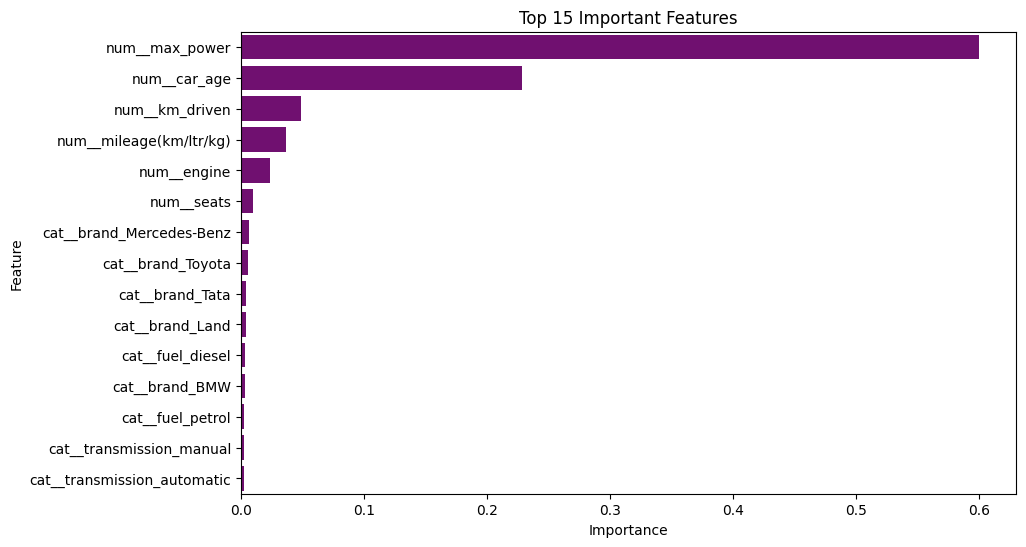

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
data=importance,
x='Importance',
y='Feature',
color="purple"
)

plt.title("Top 15 Important Features")
plt.show()

## Conclusion

This project successfully developed a Car Price Prediction model using machine learning techniques to estimate the selling price of used cars based on features such as brand, car age, fuel type, transmission, engine capacity, mileage, maximum power, ownership history, and kilometers driven.

During the project, the dataset was thoroughly preprocessed by handling missing values, removing duplicate records, cleaning inconsistent categorical values, and performing feature engineering. New features such as Car Age and Brand were created to improve the model's predictive capability. Exploratory Data Analysis (EDA) provided valuable insights into the distribution of selling prices and the relationships between different features and the target variable.

Three regression models were trained and evaluated:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Among them, the Random Forest Regressor achieved the best overall performance, producing the lowest prediction errors and the highest R² score (typically around 0.95–0.97), making it the most reliable model for this dataset.

Feature importance analysis revealed that variables such as Car Age, Maximum Power, Engine Capacity, Kilometers Driven, and Brand had the greatest influence on predicting the selling price.

Overall, this project demonstrates that machine learning can accurately estimate the market value of used cars and can be applied in real-world applications such as online car marketplaces, dealership pricing systems, and vehicle valuation tools. Future improvements could include hyperparameter tuning, testing advanced algorithms such as XGBoost or CatBoost, and incorporating additional features such as accident history, insurance status, and service records to further improve prediction accuracy.